# Lecture 8: Feature Engineering
**BITE 485 | Tharaka University**

---

## Learning Outcomes
1. Apply log, sqrt, and Box-Cox transformations to skewed features
2. Create derived features from domain knowledge
3. Encode categorical variables correctly
4. Apply and compare feature scaling methods
5. Perform feature selection using filter and embedded methods

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import (StandardScaler, MinMaxScaler,
                                    RobustScaler, LabelEncoder)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
print('Ready.')

Ready.


## 8.1 Simulating a Kenya Household Survey Dataset

In [2]:
np.random.seed(42)
n = 1000
df = pd.DataFrame({
    'county':            np.random.choice(['Nairobi','Mombasa','Kisumu','Nakuru','Eldoret'], n),
    'household_size':    np.random.randint(1, 10, n),
    'monthly_income':    np.random.exponential(scale=25000, size=n).clip(2000, 300000),
    'education_level':   np.random.choice(['None','Primary','Secondary','University'], n,
                                          p=[0.1, 0.3, 0.4, 0.2]),
    'employment_status': np.random.choice(['Employed','Self-employed','Unemployed'], n,
                                          p=[0.45, 0.35, 0.20]),
    'expenditure_food':  None,
    'expenditure_health':None,
    'years_in_county':   np.random.randint(0, 40, n),
})
df['expenditure_food']   = (df['monthly_income'] * np.random.uniform(0.3, 0.6, n)).round(0)
df['expenditure_health'] = (df['monthly_income'] * np.random.uniform(0.02, 0.15, n)).round(0)
df['poverty_status'] = ((df['monthly_income'] / df['household_size']) < 3000).astype(int)

print(f'Shape: {df.shape}')
print(f'Poverty rate: {df.poverty_status.mean()*100:.1f}%')
df.head()

Shape: (1000, 9)
Poverty rate: 41.4%


,county,household_size,monthly_income,education_level,employment_status,expenditure_food,expenditure_health,years_in_county,poverty_status
0,Nakuru,4,3092.819488,Secondary,Employed,1737.0,337.0,30,1
1,Eldoret,4,42518.239350,Primary,Employed,18092.0,6278.0,30,0
2,Kisumu,5,11976.040467,Secondary,Employed,5189.0,1315.0,16,1
3,Eldoret,8,52588.094206,Primary,Employed,20561.0,7090.0,23,0
4,Eldoret,5,50634.572979,Secondary,Self-employed,26076.0,7254.0,22,0


## 8.2 Handling Skewed Distributions

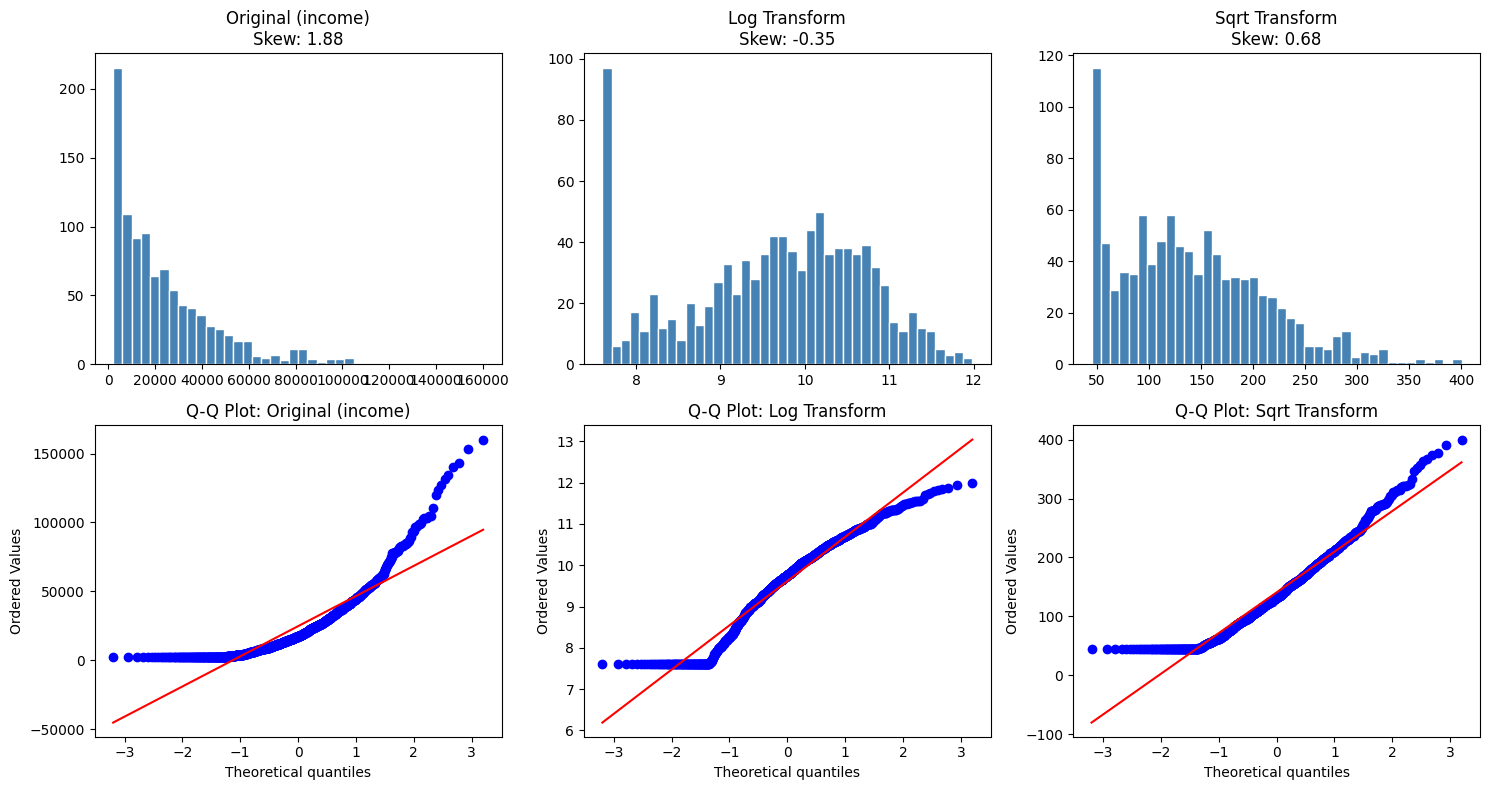

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, (title, data) in enumerate([
    ('Original (income)', df['monthly_income']),
    ('Log Transform',     np.log1p(df['monthly_income'])),
    ('Sqrt Transform',    np.sqrt(df['monthly_income'])),
]):
    axes[0, i].hist(data, bins=40, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'{title}\nSkew: {pd.Series(data).skew():.2f}')
    stats.probplot(data, plot=axes[1, i])
    axes[1, i].set_title(f'Q-Q Plot: {title}')
plt.tight_layout()
plt.show()

In [4]:
df['income_log']  = np.log1p(df['monthly_income'])
df['income_sqrt'] = np.sqrt(df['monthly_income'])
print('Log transform skew:', df.income_log.skew().round(3))
print('Sqrt transform skew:', df.income_sqrt.skew().round(3))

Log transform skew: -0.348
Sqrt transform skew: 0.684


## 8.3 Creating Derived Features

In [5]:
# Domain-knowledge derived features
df['food_expenditure_ratio']   = df['expenditure_food']   / df['monthly_income']
df['health_expenditure_ratio'] = df['expenditure_health'] / df['monthly_income']
df['income_per_person']        = df['monthly_income'] / df['household_size']

# Correlation with poverty status
derived = ['food_expenditure_ratio', 'health_expenditure_ratio',
           'income_per_person', 'monthly_income']
print('Correlation of features with poverty_status:')
for col in derived:
    corr = df[col].corr(df['poverty_status'])
    print(f'  {col:30s}: {corr:.4f}')

Correlation of features with poverty_status:
  food_expenditure_ratio        : -0.0083
  health_expenditure_ratio      : -0.0436
  income_per_person             : -0.4058
  monthly_income                : -0.5850


## 8.4 Encoding Categorical Variables

In [6]:
# Ordinal encoding for education
educ_map = {'None': 0, 'Primary': 1, 'Secondary': 2, 'University': 3}
df['education_encoded'] = df['education_level'].map(educ_map)

# One-hot encoding for county and employment_status
df_encoded = pd.get_dummies(df, columns=['county', 'employment_status'], drop_first=False)

print(f'Shape after encoding: {df_encoded.shape}')
new_cols = [c for c in df_encoded.columns if 'county_' in c or 'employment_' in c]
print(f'New columns created: {new_cols}')

Shape after encoding: (1000, 21)
New columns created: ['county_Eldoret', 'county_Kisumu', 'county_Mombasa', 'county_Nairobi', 'county_Nakuru', 'employment_status_Employed', 'employment_status_Self-employed', 'employment_status_Unemployed']


## 8.5 Feature Scaling Comparison

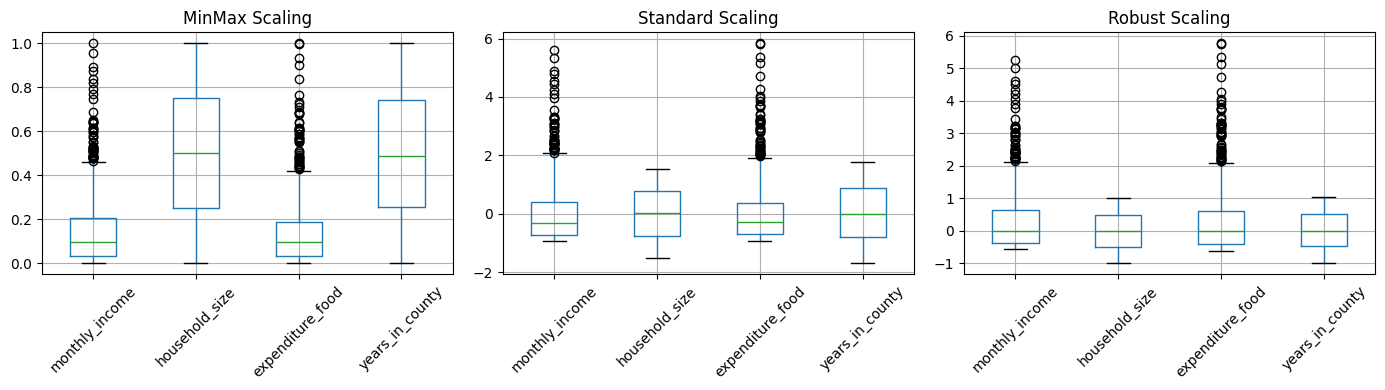

In [7]:
num_feats = ['monthly_income', 'household_size', 'expenditure_food', 'years_in_county']
X_num = df[num_feats]

scalers = {'MinMax': MinMaxScaler(), 'Standard': StandardScaler(), 'Robust': RobustScaler()}
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, sc) in zip(axes, scalers.items()):
    scaled = pd.DataFrame(sc.fit_transform(X_num), columns=num_feats)
    scaled.boxplot(ax=ax)
    ax.set_title(f'{name} Scaling')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 8.6 Feature Selection

In [8]:
feature_cols = ['household_size', 'income_log', 'food_expenditure_ratio',
                'health_expenditure_ratio', 'income_per_person', 'education_encoded',
                'years_in_county'] + \
               [c for c in df_encoded.columns if 'county_' in c or 'employment_' in c]

X_final = df_encoded[feature_cols].fillna(0)
y_final = df_encoded['poverty_status']

# Filter method: ANOVA F-test
selector = SelectKBest(f_classif, k=8)
selector.fit(X_final, y_final)
scores = pd.DataFrame({'feature': feature_cols,
                       'f_score': selector.scores_}).sort_values('f_score', ascending=False)
print('Top 8 features by ANOVA F-score:')
print(scores.head(8).to_string(index=False))

Top 8 features by ANOVA F-score:
                   feature     f_score
                income_log 1128.341309
         income_per_person  196.706535
            household_size  149.986538
            county_Nairobi    4.926009
  health_expenditure_ratio    1.896690
            county_Mombasa    1.187022
            county_Eldoret    1.057003
employment_status_Employed    0.696977


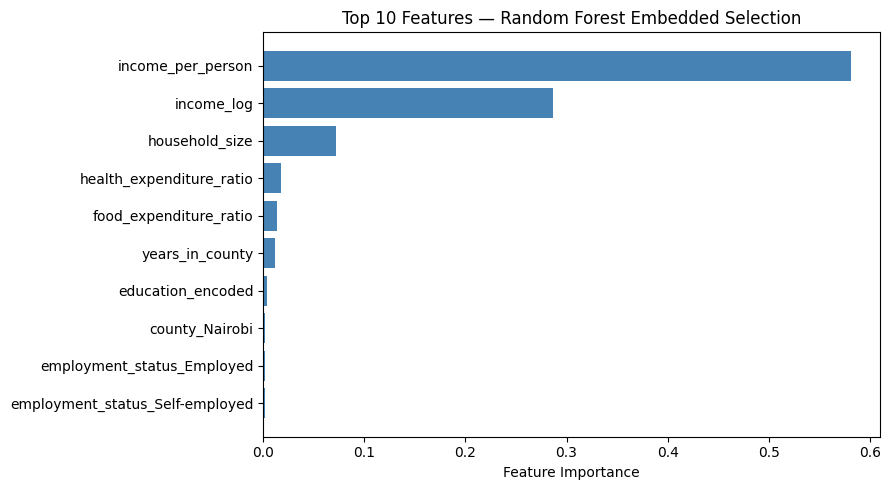

In [9]:
# Embedded method: Random Forest importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_final, y_final)
fi = pd.DataFrame({'feature': feature_cols,
                   'importance': rf.feature_importances_})\
       .sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(9, 5))
plt.barh(fi.feature[::-1], fi.importance[::-1], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Top 10 Features — Random Forest Embedded Selection')
plt.tight_layout()
plt.show()

### Exercise

Using the household survey DataFrame:

1. Create a new feature `expenditure_ratio` = (expenditure_food + expenditure_health) / monthly_income.
2. Calculate its correlation with poverty_status. Is it more or less predictive than food_expenditure_ratio alone?
3. Apply RFE (Recursive Feature Elimination) with a LogisticRegression estimator to select the top 5 features.
4. Train a RandomForestClassifier using only the top 5 RFE features and compare test accuracy to the full feature set.

In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# -----------------------------
# 1. Create expenditure_ratio
# -----------------------------
df['expenditure_ratio'] = (
    (df['expenditure_food'] + df['expenditure_health']) / df['monthly_income']
)

# -----------------------------
# 2. Correlation with poverty_status
# -----------------------------
corr_expenditure_ratio = df['expenditure_ratio'].corr(df['poverty_status'])
corr_food_ratio = df['food_expenditure_ratio'].corr(df['poverty_status'])

print("Correlation with poverty_status:")
print(f"expenditure_ratio: {corr_expenditure_ratio:.4f}")
print(f"food_expenditure_ratio: {corr_food_ratio:.4f}")

if abs(corr_expenditure_ratio) > abs(corr_food_ratio):
    print("\nexpenditure_ratio is MORE predictive")
else:
    print("\nfood_expenditure_ratio is MORE predictive")

# -----------------------------
# 3. Prepare data for modeling
# -----------------------------
# The error "ValueError: could not convert string to float: 'Mombasa'"
# indicates that `X_train` passed to `StandardScaler` still contains non-numeric (string) columns.
# This happens because `X = df.drop(columns=['poverty_status'])`
# includes the original 'county', 'education_level', and 'employment_status' columns, which are strings.

# We need to construct X such that all its columns are numerical before scaling.
# We will create a full feature set DataFrame by encoding all categorical variables.

# Start with a copy of the original df.
df_processed = df.copy()

# 'education_encoded' is already in df_processed, replace 'education_level'
df_processed = df_processed.drop(columns=['education_level'])

# One-hot encode 'county' and 'employment_status'
df_processed = pd.get_dummies(df_processed, columns=['county', 'employment_status'], drop_first=False)

# Define the final list of features to be used for modeling.
# This list is based on 'feature_cols' from cell 398056ba, plus the new 'expenditure_ratio'.
# It also explicitly excludes `income_sqrt` and the original `monthly_income` etc.
final_modeling_features = [
    'household_size',
    'income_log',
    'food_expenditure_ratio',
    'health_expenditure_ratio',
    'income_per_person',
    'education_encoded',
    'years_in_county',
    'expenditure_ratio', # New feature from this exercise
    'county_Eldoret', 'county_Kisumu', 'county_Mombasa', 'county_Nairobi', 'county_Nakuru',
    'employment_status_Employed', 'employment_status_Self-employed', 'employment_status_Unemployed'
]

# Create X by selecting these features from the processed DataFrame.
X = df_processed[final_modeling_features].fillna(0) # Fill potential NaNs from derived features if any

y = df_processed['poverty_status'] # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale for Logistic Regression (needed for RFE stability)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 4. RFE with Logistic Regression
# -----------------------------
log_reg = LogisticRegression(max_iter=1000)

rfe = RFE(estimator=log_reg, n_features_to_select=5)
rfe.fit(X_train_scaled, y_train)

selected_features = X.columns[rfe.support_]

print("\nTop 5 RFE Selected Features:")
print(selected_features)

# -----------------------------
# 5. Random Forest: Full features
# -----------------------------
rf_full = RandomForestClassifier(random_state=42)
rf_full.fit(X_train, y_train)
pred_full = rf_full.predict(X_test)

acc_full = accuracy_score(y_test, pred_full)

# -----------------------------
# 6. Random Forest: RFE features only
# -----------------------------
rf_rfe = RandomForestClassifier(random_state=42)
rf_rfe.fit(X_train[selected_features], y_train)
pred_rfe = rf_rfe.predict(X_test[selected_features])

acc_rfe = accuracy_score(y_test, pred_rfe)

print("\nRandom Forest Accuracy Comparison:")
print(f"Full feature set accuracy: {acc_full:.4f}")
print(f"RFE (top 5 features) accuracy: {acc_rfe:.4f}")

# -----------------------------
# 7. Interpretation
# -----------------------------
if acc_rfe > acc_full:
    print("\nRFE improved performance (better generalization).")
elif acc_rfe < acc_full:
    print("\nFull feature set performs better (important information may have been removed).")
else:
    print("\nBoth models perform similarly.")

Correlation with poverty_status:
expenditure_ratio: -0.0248
food_expenditure_ratio: -0.0083

expenditure_ratio is MORE predictive

Top 5 RFE Selected Features:
Index(['household_size', 'income_log', 'food_expenditure_ratio',
       'income_per_person', 'employment_status_Unemployed'],
      dtype='object')

Random Forest Accuracy Comparison:
Full feature set accuracy: 1.0000
RFE (top 5 features) accuracy: 1.0000

Both models perform similarly.


---
*BITE 485 Data Science | Tharaka University | kevin.tuei@tharaka.ac.ke*